In [2]:
import pandas as pd

dtype_dict = {
    'VendorID': 'float32',
    'passenger_count': 'float32',  
    'trip_distance': 'float32',
    'RatecodeID': 'float32',       
    'store_and_fwd_flag': 'category',
    'PULocationID': 'int16',
    'DOLocationID': 'int16',
    'payment_type': 'float32',     
    'fare_amount': 'float32',
    'extra': 'float32',
    'mta_tax': 'float32',
    'tip_amount': 'float32',
    'tolls_amount': 'float32',
    'improvement_surcharge': 'float32',
    'total_amount': 'float32',
    'congestion_surcharge': 'float32'
}


# Datetime columns to parse
parse_dates = ['tpep_pickup_datetime', 'tpep_dropoff_datetime']

# Load the full dataset
df = pd.read_csv(
    '../data/data.csv',
    dtype=dtype_dict,
    parse_dates=parse_dates
)

# Step 1: Add a boolean column for canceled flag
df['possibly_canceled'] = (
    (df['fare_amount'] <= 0) |
    (df['trip_distance'] <= 0) |
    (df['total_amount'] <= 0) |
    (df['passenger_count'].isna()) | (df['passenger_count'] <= 0) |
    (df['VendorID'].isna()) | (df['VendorID'] <= 0) |
    (df['payment_type'].isna()) | (df['payment_type'] <= 0) |
    (df['store_and_fwd_flag'].isna()) | (~df['store_and_fwd_flag'].isin(['Y', 'N']))
)

# All suspect rows
canceled_trips = df[df['possibly_canceled']].copy()

# All clean trips
valid_trips = df[~df['possibly_canceled']].copy()
df = valid_trips.reset_index(drop=True)
df.head()
print(f"Flagged {len(canceled_trips)} possibly canceled transactions.")


Flagged 263564 possibly canceled transactions.


In [31]:
# Task 1: Extract all trips with trip_distance > 50
long_trips = df[df['trip_distance'] > 50].copy()
long_trips.reset_index(drop=True, inplace=True)

print(f"Extracted {len(long_trips)} trips with trip_distance > 50.")
long_trips


Extracted 358 trips with trip_distance > 50.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,possibly_canceled,duration,duration_minutes,pickup_interval
0,2.0,2020-01-01 01:53:07,2020-01-01 03:54:41,1.0,52.299999,5.0,N,262,265,1.0,...,0.0,61.779999,6.120000,0.3,370.700012,2.5,False,7294.0,121.566667,2020-01-01 01:30:00
1,2.0,2020-01-01 02:05:07,2020-01-01 03:03:10,1.0,51.230000,5.0,N,264,264,1.0,...,0.5,100.779999,6.120000,0.3,436.700012,0.0,False,3483.0,58.050000,2020-01-01 02:00:00
2,1.0,2020-01-01 03:05:54,2020-01-01 04:16:26,1.0,53.799999,5.0,N,132,265,1.0,...,0.0,53.349998,16.620001,0.3,320.269989,0.0,False,4232.0,70.533333,2020-01-01 03:00:00
3,2.0,2020-01-01 05:36:12,2020-01-01 06:40:06,1.0,55.230000,5.0,N,132,265,2.0,...,0.5,0.000000,18.260000,0.3,189.059998,0.0,False,3834.0,63.900000,2020-01-01 05:30:00
4,2.0,2020-01-01 07:40:30,2020-01-01 08:40:01,1.0,54.189999,5.0,N,132,265,1.0,...,0.0,0.000000,12.240000,0.3,242.539993,0.0,False,3571.0,59.516667,2020-01-01 07:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,2.0,2020-01-31 19:43:38,2020-01-31 21:12:59,1.0,53.169998,5.0,N,138,264,2.0,...,0.5,0.000000,0.000000,0.3,183.300003,0.0,False,5361.0,89.350000,2020-01-31 19:30:00
354,2.0,2020-01-31 22:06:26,2020-01-31 23:40:19,3.0,56.490002,5.0,N,170,265,1.0,...,0.0,25.700001,0.000000,0.3,128.500000,2.5,False,5633.0,93.883333,2020-01-31 22:00:00
355,2.0,2020-01-31 22:47:26,2020-01-31 23:49:14,1.0,51.830002,5.0,N,132,265,1.0,...,0.5,48.959999,23.990000,0.3,293.750000,0.0,False,3708.0,61.800000,2020-01-31 22:30:00
356,2.0,2020-01-31 23:45:36,2020-02-01 01:00:25,5.0,57.990002,4.0,N,107,265,1.0,...,0.5,38.240002,6.120000,0.3,293.160004,2.5,False,4489.0,74.816667,2020-01-31 23:30:00


In [4]:
# Task 2: Extract all trips where payment_type is missing
missing_payment = df[df['payment_type'].isna()].copy()

print(f"Found {len(missing_payment)} trips with missing payment_type.")
missing_payment


Found 0 trips with missing payment_type.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,possibly_canceled


In [6]:
# Task 3: Count trips for each (PULocationID, DOLocationID) pair
trip_counts = df.groupby(['PULocationID', 'DOLocationID']).size().reset_index(name='trip_count')

print(f"Found {len(trip_counts)} unique pickup–dropoff pairs.")
trip_counts


Found 23245 unique pickup–dropoff pairs.


,PULocationID,DOLocationID,trip_count
0,1,1,143
1,1,50,1
2,1,68,1
3,1,138,2
4,1,140,1
...,...,...,...
23240,265,259,1
23241,265,261,1
23242,265,263,4
23243,265,264,37


In [6]:
# Task 4: Isolate rows with missing values in critical columns
cols_to_check = ['VendorID', 'passenger_count', 'store_and_fwd_flag', 'payment_type']

# Extract the "bad" rows
bad = df[df[cols_to_check].isna().any(axis=1)].copy()

# Remove them from df
df_cleaned_final = df.drop(index=bad.index).reset_index(drop=True)

print(f"Bad rows extracted: {len(bad)}")
print(f"Remaining rows in cleaned DataFrame: {len(df)}")


Bad rows extracted: 0
Remaining rows in cleaned DataFrame: 6141444


In [8]:
# Task 5: Add a 'duration' column (in seconds)
df['duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()

# Also create duration in minutes since unit not specified
df['duration_minutes'] = df['duration'] / 60

# Preview the result
df[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'duration', 'duration_minutes']].head()

# Find rows with invalid durations (≤ 0 seconds)
invalid_duration = df[df['duration'] <= 0]

print(f"Trips with invalid (≤ 0) duration: {len(invalid_duration)}")
invalid_duration.head()
invalid_duration.to_csv('../data/invalid_duration_rows.csv', index=False)




Trips with invalid (≤ 0) duration: 182


In [9]:
# Task 6: Count trips per pickup location
pickup_counts = df['PULocationID'].value_counts().reset_index()

# Rename the columns for clarity
pickup_counts.columns = ['PULocationID', 'trip_count']

# Display result
print(f"Number of unique pickup locations: {pickup_counts.shape[0]}")
pickup_counts


Number of unique pickup locations: 256


,PULocationID,trip_count
0,237,285373
1,161,274568
2,236,265754
3,162,229142
4,230,221620
...,...,...
251,105,2
252,99,2
253,59,2
254,30,1


In [10]:
# Task 7: Create 30-minute pickup time intervals
def round_to_half_hour(dt):
    return dt.replace(minute=0, second=0, microsecond=0) if dt.minute < 30 else dt.replace(minute=30, second=0, microsecond=0)

df['pickup_interval'] = df['tpep_pickup_datetime'].apply(round_to_half_hour)

# Preview the new column
df[['tpep_pickup_datetime', 'pickup_interval']].head()


,tpep_pickup_datetime,pickup_interval
0,2020-01-01 00:28:15,2020-01-01 00:00:00
1,2020-01-01 00:35:39,2020-01-01 00:30:00
2,2020-01-01 00:47:41,2020-01-01 00:30:00
3,2020-01-01 00:55:23,2020-01-01 00:30:00
4,2020-01-01 00:09:44,2020-01-01 00:00:00


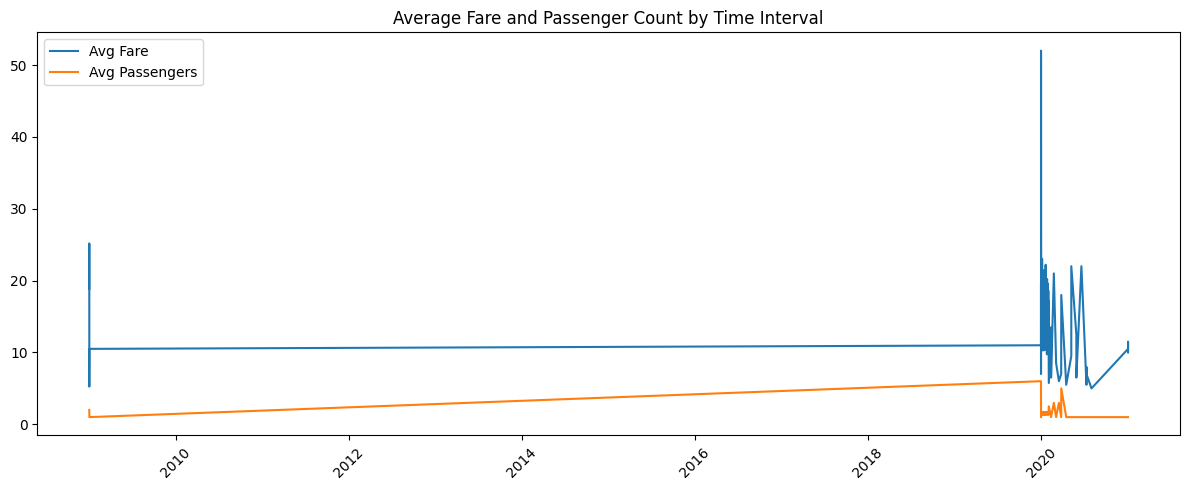

In [11]:
# Task 8: Average passengers and fare amount per 30-minute interval
import matplotlib.pyplot as plt
interval_stats = df.groupby('pickup_interval').agg(
    avg_passengers=('passenger_count', 'mean'),
    avg_fare_amount=('fare_amount', 'mean')
).reset_index()

# Round for cleaner output
interval_stats['avg_passengers'] = interval_stats['avg_passengers'].round(2)
interval_stats['avg_fare_amount'] = interval_stats['avg_fare_amount'].round(2)

# Display result
interval_stats.sort_values('pickup_interval').head()
plt.figure(figsize=(12, 5))
plt.plot(interval_stats['pickup_interval'], interval_stats['avg_fare_amount'], label='Avg Fare')
plt.plot(interval_stats['pickup_interval'], interval_stats['avg_passengers'], label='Avg Passengers')
plt.legend()
plt.xticks(rotation=45)
plt.title('Average Fare and Passenger Count by Time Interval')
plt.tight_layout()
plt.show()


In [14]:
# Task 9: Average fare per payment_type and interval
fare_by_type_interval = df.groupby(['pickup_interval', 'payment_type']).agg(
    avg_fare_amount=('fare_amount', 'mean')
).reset_index()

# Round values for readability
fare_by_type_interval['avg_fare_amount'] = fare_by_type_interval['avg_fare_amount'].round(2)

# Display result
fare_by_type_interval.sort_values(['pickup_interval', 'payment_type']).head()




,pickup_interval,payment_type,avg_fare_amount
0,2008-12-31 23:00:00,1.0,13.5
1,2008-12-31 23:00:00,2.0,26.0
2,2008-12-31 23:30:00,1.0,52.0
3,2008-12-31 23:30:00,2.0,8.0
4,2009-01-01 00:00:00,1.0,15.0


In [15]:
# Task 10: Find the interval with the highest average fare for each payment type
max_fare_intervals = fare_by_type_interval.loc[
    fare_by_type_interval.groupby('payment_type')['avg_fare_amount'].idxmax()
].reset_index(drop=True)

# Display result
max_fare_intervals

,pickup_interval,payment_type,avg_fare_amount
0,2008-12-31 23:30:00,1.0,52.000000
1,2009-01-01 00:00:00,2.0,26.440001
2,2020-01-21 01:00:00,3.0,51.500000
3,2020-01-16 03:30:00,4.0,115.500000


In [16]:
# Task 11: For each payment type, determine the interval when the overall ratio between the tip and the fare amounts is maximum

# Step 1: Group by interval and payment type
tip_fare_ratio_df = df.groupby(['pickup_interval', 'payment_type']).agg(
    avg_tip=('tip_amount', 'mean'),
    avg_fare=('fare_amount', 'mean')
).reset_index()

# Step 2: Calculate ratio
tip_fare_ratio_df['tip_to_fare_ratio'] = tip_fare_ratio_df['avg_tip'] / tip_fare_ratio_df['avg_fare']

# Step 3: Find max ratio per payment_type
max_tip_ratio = tip_fare_ratio_df.loc[
    tip_fare_ratio_df.groupby('payment_type')['tip_to_fare_ratio'].idxmax()
].reset_index(drop=True)

# Round for readability
max_tip_ratio[['avg_tip', 'avg_fare', 'tip_to_fare_ratio']] = max_tip_ratio[['avg_tip', 'avg_fare', 'tip_to_fare_ratio']].round(2)

# Display result
max_tip_ratio


,pickup_interval,payment_type,avg_tip,avg_fare,tip_to_fare_ratio
0,2020-03-04 10:00:00,1.0,3.54,8.50,0.42
1,2020-01-29 10:00:00,2.0,0.01,11.69,0.00
2,2020-01-01 21:00:00,3.0,3.64,10.14,0.36
3,2020-01-29 10:00:00,4.0,1.32,9.33,0.14


In [17]:
# Task 12: Average fare per pickup location
avg_fare_by_pickup = df.groupby('PULocationID')['fare_amount'].mean().reset_index()

# Renaming for clarity
avg_fare_by_pickup.columns = ['PULocationID', 'avg_fare_amount']

# Round the values
avg_fare_by_pickup['avg_fare_amount'] = avg_fare_by_pickup['avg_fare_amount'].round(2)

# Find the pickup location with the highest average fare
highest_avg_fare = avg_fare_by_pickup.sort_values('avg_fare_amount', ascending=False).head(1)

# Display result
highest_avg_fare



,PULocationID,avg_fare_amount
195,204,107.0


In [18]:
# Task 13: Build a new dataframe common where, for each pickup location we keep all trips to the 5 most common destinations

# Step 1: Count trips for each (PULocationID, DOLocationID) pair
trip_counts = df.groupby(['PULocationID', 'DOLocationID']).size().reset_index(name='trip_count')

# Step 2: For each pickup location, get the top 5 destinations
top_5_destinations = trip_counts.sort_values(['PULocationID', 'trip_count'], ascending=[True, False])
top_5_destinations = top_5_destinations.groupby('PULocationID').head(5)

# Step 3: Merge with original df to keep only matching trips
common = df.merge(top_5_destinations[['PULocationID', 'DOLocationID']], on=['PULocationID', 'DOLocationID'])

# Step 4: Reset index and preview
common.reset_index(drop=True, inplace=True)
print(f"common dataframe has {len(common)} rows.")
common.head()


common dataframe has 1879559 rows.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,possibly_canceled,duration,duration_minutes,pickup_interval
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,1.0,N,238,239,1.0,...,0.5,1.47,0.0,0.3,11.27,2.5,False,288.0,4.800000,2020-01-01 00:00:00
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,1.0,N,239,238,1.0,...,0.5,1.50,0.0,0.3,12.30,2.5,False,445.0,7.416667,2020-01-01 00:30:00
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,1.0,N,238,238,1.0,...,0.5,1.00,0.0,0.3,10.80,2.5,False,371.0,6.183333,2020-01-01 00:30:00
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,1.0,N,238,151,1.0,...,0.5,1.36,0.0,0.3,8.16,0.0,False,291.0,4.850000,2020-01-01 00:30:00
4,2.0,2020-01-01 00:09:44,2020-01-01 00:10:37,1.0,0.03,1.0,N,7,193,2.0,...,0.5,0.00,0.0,0.3,3.80,0.0,False,53.0,0.883333,2020-01-01 00:00:00


In [19]:
# Task 14: Average fare amount by interval and payment_type on common dataset
common_fare_stats = common.groupby(['pickup_interval', 'payment_type']).agg(
    avg_fare_amount=('fare_amount', 'mean')
).reset_index()

# Round for readability
common_fare_stats['avg_fare_amount'] = common_fare_stats['avg_fare_amount'].round(2)

# Preview result
common_fare_stats.sort_values(['pickup_interval', 'payment_type']).head()


,pickup_interval,payment_type,avg_fare_amount
0,2008-12-31 23:00:00,1.0,6.00
1,2008-12-31 23:30:00,2.0,3.50
2,2009-01-01 00:00:00,2.0,3.75
3,2009-01-01 00:30:00,2.0,41.50
4,2009-01-01 01:00:00,2.0,10.00


In [20]:
# Task 15: Compute difference in average fare amount
fare_comparison = pd.merge(
    common_fare_stats,
    fare_by_type_interval,
    on=['pickup_interval', 'payment_type'],
    suffixes=('_common', '_full')
)

# Compute the difference
fare_comparison['fare_diff'] = fare_comparison['avg_fare_amount_common'] - fare_comparison['avg_fare_amount_full']

# Round for readability
fare_comparison['fare_diff'] = fare_comparison['fare_diff'].round(2)

# Preview result
fare_comparison.head()



,pickup_interval,payment_type,avg_fare_amount_common,avg_fare_amount_full,fare_diff
0,2008-12-31 23:00:00,1.0,6.00,13.500000,-7.500000
1,2008-12-31 23:30:00,2.0,3.50,8.000000,-4.500000
2,2009-01-01 00:00:00,2.0,3.75,26.440001,-22.690001
3,2009-01-01 00:30:00,2.0,41.50,24.250000,17.250000
4,2009-01-01 01:00:00,2.0,10.00,10.000000,0.000000


In [21]:
# Task 16: Compute ratio of fare difference to original average fare
fare_comparison['fare_diff_ratio'] = (fare_comparison['fare_diff'] / fare_comparison['avg_fare_amount_full']).round(4)

# Preview result
fare_comparison[['pickup_interval', 'payment_type', 'fare_diff', 'avg_fare_amount_full', 'fare_diff_ratio']].head()


,pickup_interval,payment_type,fare_diff,avg_fare_amount_full,fare_diff_ratio
0,2008-12-31 23:00:00,1.0,-7.500000,13.500000,-0.5556
1,2008-12-31 23:30:00,2.0,-4.500000,8.000000,-0.5625
2,2009-01-01 00:00:00,2.0,-22.690001,26.440001,-0.8582
3,2009-01-01 00:30:00,2.0,17.250000,24.250000,0.7113
4,2009-01-01 01:00:00,2.0,0.000000,10.000000,0.0000


In [30]:
# Task 17 Build chain of trips

# Step 1: Sort by Vendor and Pickup Time
df_sorted = df.sort_values(by=['VendorID', 'tpep_pickup_datetime']).reset_index(drop=True)

# Step 2: Shift relevant columns
df_sorted['next_pickup'] = df_sorted['tpep_pickup_datetime'].shift(-1)
df_sorted['next_pu_loc'] = df_sorted['PULocationID'].shift(-1)
df_sorted['next_vendor'] = df_sorted['VendorID'].shift(-1)
df_sorted['curr_drop_loc'] = df_sorted['DOLocationID']
df_sorted['curr_vendor'] = df_sorted['VendorID']
df_sorted['curr_dropoff'] = df_sorted['tpep_dropoff_datetime']

# Step 3: Compute time gap
df_sorted['gap'] = (df_sorted['next_pickup'] - df_sorted['curr_dropoff']).dt.total_seconds()

# Step 4: Create chain 
chain_mask = (
    (df_sorted['curr_vendor'] == df_sorted['next_vendor']) &
    (df_sorted['curr_drop_loc'] == df_sorted['next_pu_loc']) &
    (df_sorted['gap'] > 0) & (df_sorted['gap'] <= 120)
)

# Step 5: Assign chain IDs
df_sorted['chain'] = pd.NA
df_sorted.loc[chain_mask, 'chain'] = range(1, chain_mask.sum() + 1)
df_sorted['chain'] = df_sorted['chain'].astype('Int64')

# Step 6: Show summary
print(f"Chained trips in full dataset: {df_sorted['chain'].notna().sum()}")

# Step 7: Save to CSV
df_sorted[df_sorted['chain'].notna()].to_csv('../data/chained_trips_full.csv', index=False)



Chained trips in full dataset: 6
